# EDA Visualizations

Builds 11 charts from the already-cleaned datasets and saves each as a PNG into the `figures/` folder.

In [1]:
%pip install pandas numpy matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
os.makedirs("figures", exist_ok=True)

## Load the cleaned data

In [ ]:
traffic = pd.read_csv("cicids2017_cleaned.csv", low_memory=False)
cve = pd.read_csv("cve_raw.csv")
print(f"Traffic rows: {len(traffic)}")
print(f"CVE rows: {len(cve)}")

Traffic rows: 2520798
CVE rows: 40519


## Chart 1 - Record count per label (CIC-IDS2017)

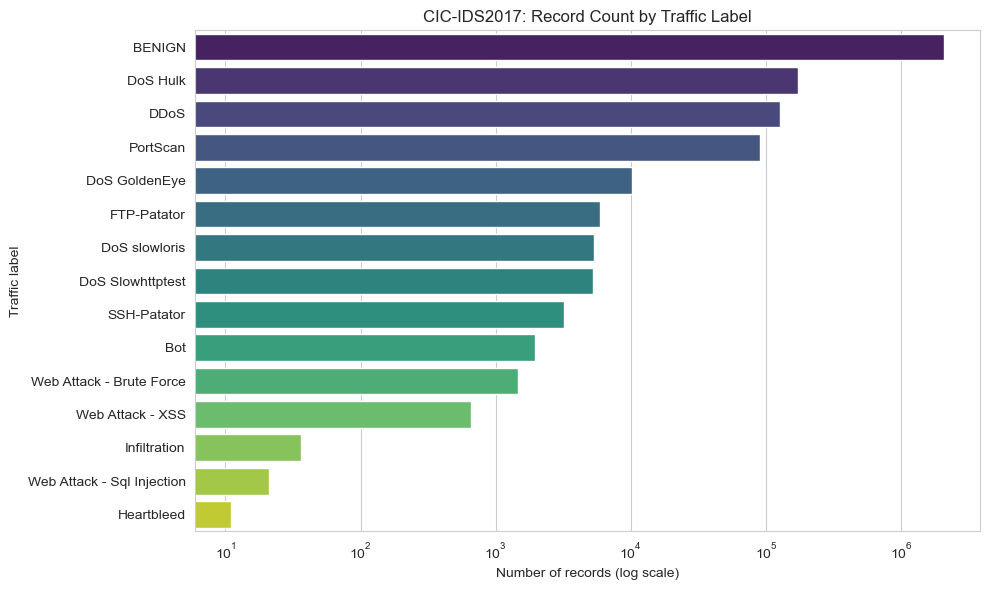

In [4]:
counts = traffic['Label'].value_counts()

plt.figure(figsize=(10, 6))
sns.barplot(x=counts.values, y=counts.index, hue=counts.index, palette="viridis", legend=False)
plt.xscale('log')
plt.xlabel('Number of records (log scale)')
plt.ylabel('Traffic label')
plt.title('CIC-IDS2017: Record Count by Traffic Label')
plt.tight_layout()
plt.savefig('figures/01_label_counts.png', dpi=150)
plt.show()

## Chart 2 - Flow duration by label (top 6 classes)

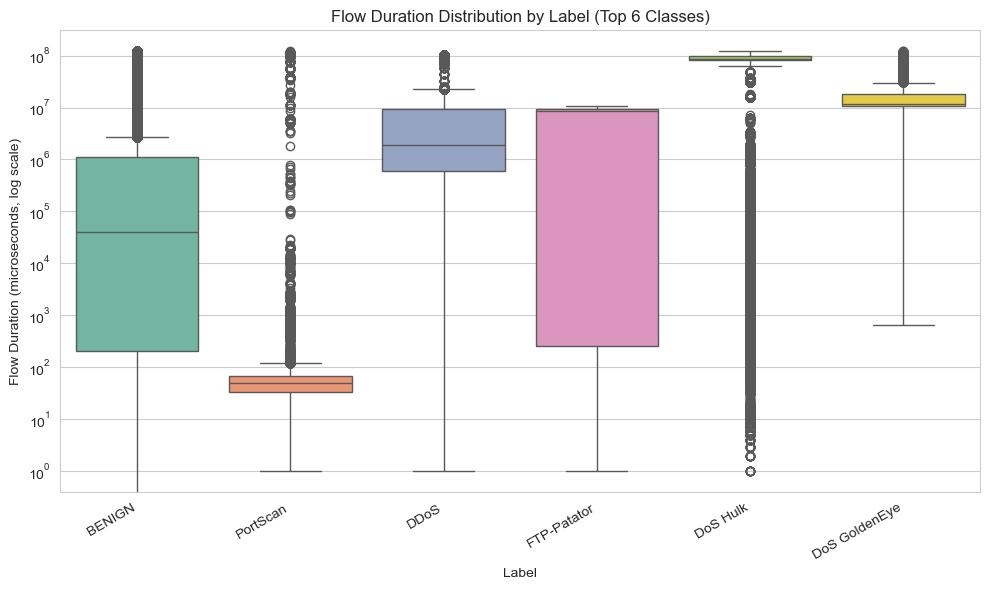

In [5]:
top6 = traffic['Label'].value_counts().head(6).index
subset = traffic[traffic['Label'].isin(top6)]

plt.figure(figsize=(10, 6))
sns.boxplot(data=subset, x='Label', y='Flow Duration', hue='Label', palette="Set2", legend=False)
plt.yscale('log')
plt.xticks(rotation=30, ha='right')
plt.ylabel('Flow Duration (microseconds, log scale)')
plt.title('Flow Duration Distribution by Label (Top 6 Classes)')
plt.tight_layout()
plt.savefig('figures/02_duration_by_label.png', dpi=150)
plt.show()

## Chart 3 - Total forward packets distribution

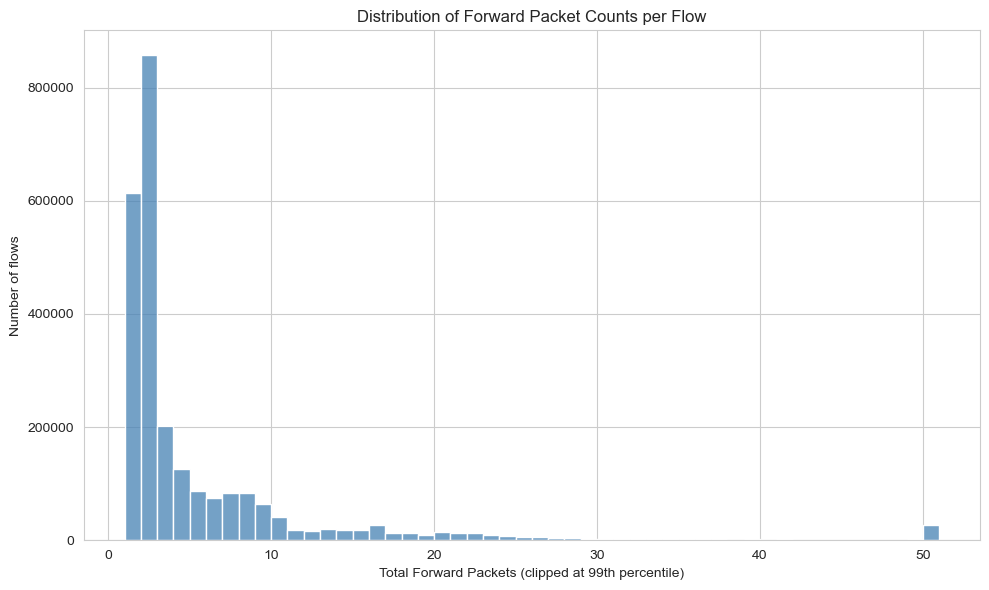

In [6]:
plt.figure(figsize=(10, 6))
sns.histplot(traffic['Total Fwd Packets'].clip(upper=traffic['Total Fwd Packets'].quantile(0.99)), bins=50, color='steelblue')
plt.xlabel('Total Forward Packets (clipped at 99th percentile)')
plt.ylabel('Number of flows')
plt.title('Distribution of Forward Packet Counts per Flow')
plt.tight_layout()
plt.savefig('figures/03_fwd_packets_distribution.png', dpi=150)
plt.show()

## Chart 4 - Correlation heatmap of key features

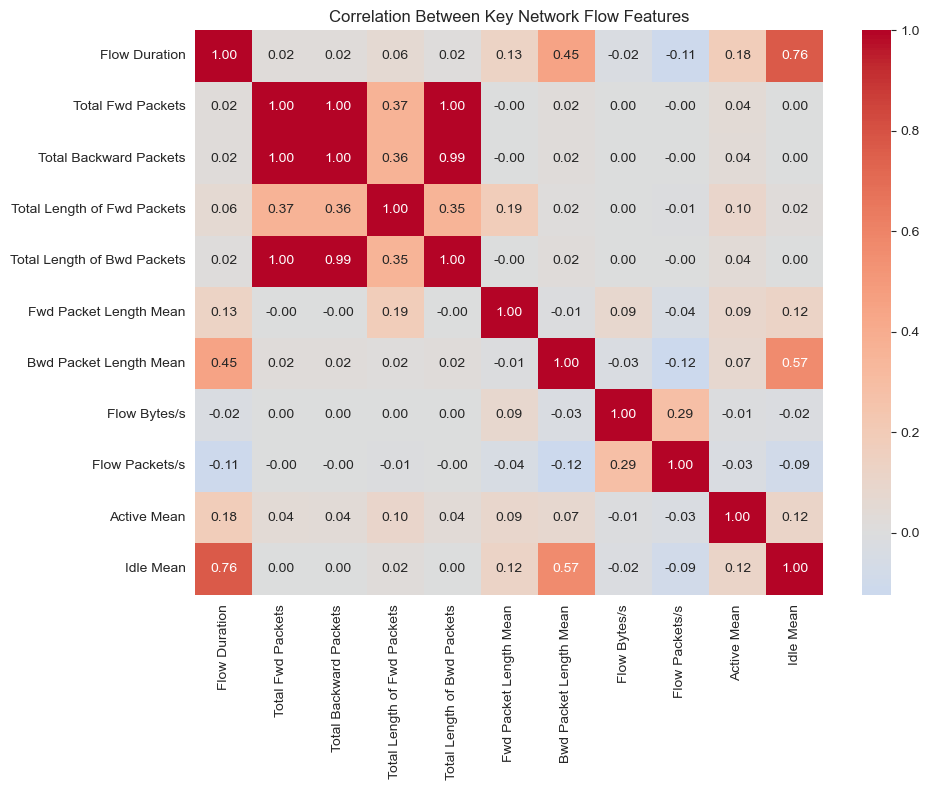

In [7]:
desired_cols = ['Flow Duration', 'Total Fwd Packets', 'Total Backward Packets',
                 'Total Length of Fwd Packets', 'Total Length of Bwd Packets',
                 'Fwd Packet Length Mean', 'Bwd Packet Length Mean',
                 'Flow Bytes/s', 'Flow Packets/s', 'Active Mean', 'Idle Mean']
cols = [c for c in desired_cols if c in traffic.columns]

corr = traffic[cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Between Key Network Flow Features')
plt.tight_layout()
plt.savefig('figures/04_correlation_heatmap.png', dpi=150)
plt.show()

## Chart 5 - Forward vs backward packets, colored by label

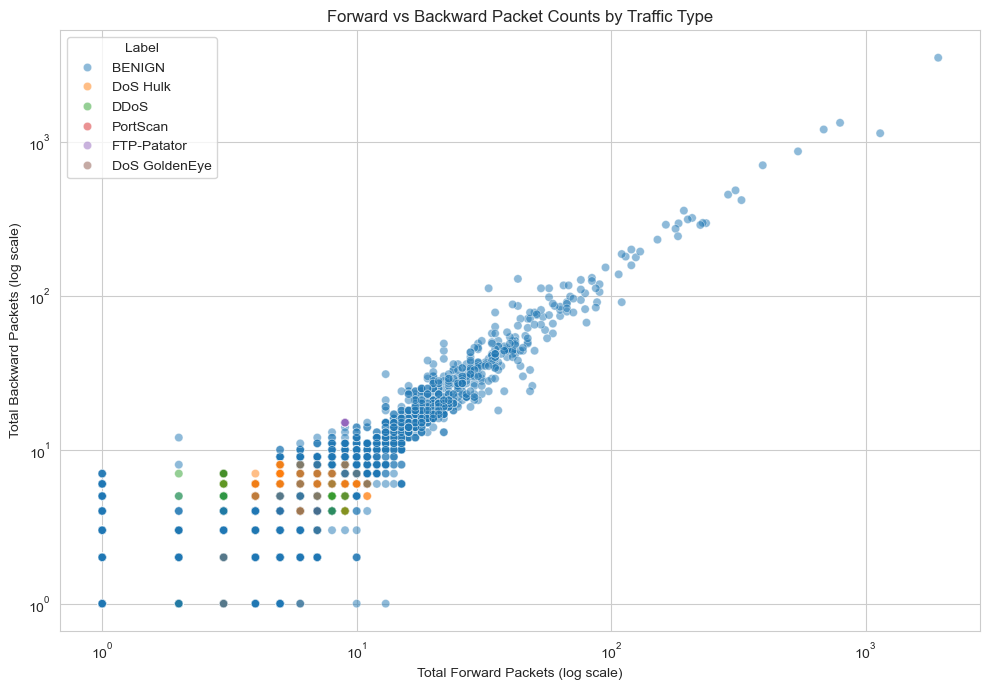

In [8]:
# Full dataset is too large to scatter-plot directly, so we sample
sample = traffic[traffic['Label'].isin(top6)].sample(8000, random_state=1)

plt.figure(figsize=(10, 7))
sns.scatterplot(data=sample, x='Total Fwd Packets', y='Total Backward Packets', hue='Label', alpha=0.5, palette="tab10")
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Total Forward Packets (log scale)')
plt.ylabel('Total Backward Packets (log scale)')
plt.title('Forward vs Backward Packet Counts by Traffic Type')
plt.tight_layout()
plt.savefig('figures/05_fwd_vs_bwd_scatter.png', dpi=150)
plt.show()

## Chart 6 - Mean flow duration per attack type

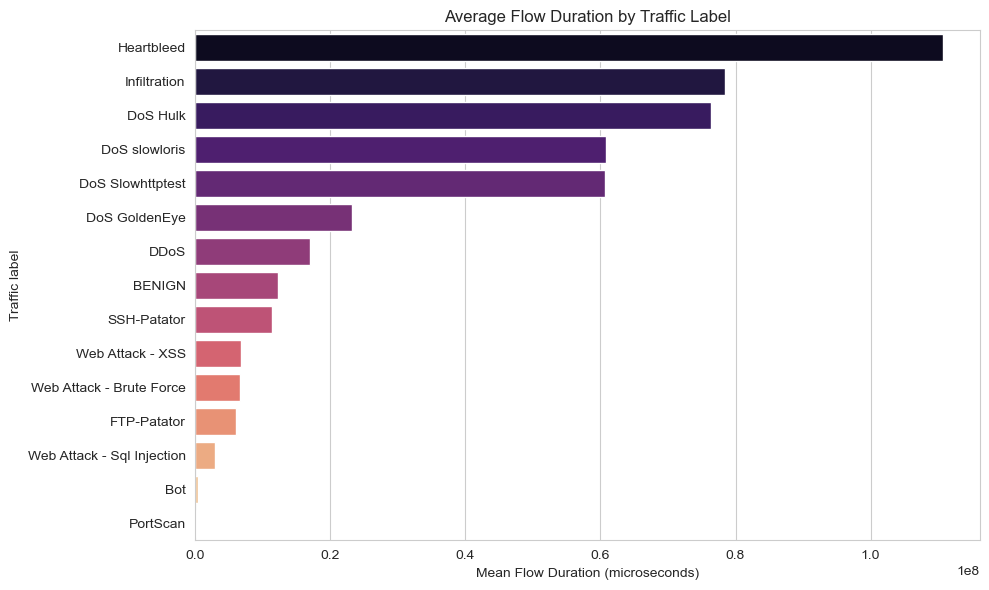

In [9]:
mean_duration = traffic.groupby('Label')['Flow Duration'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=mean_duration.values, y=mean_duration.index, hue=mean_duration.index, palette="magma", legend=False)
plt.xlabel('Mean Flow Duration (microseconds)')
plt.ylabel('Traffic label')
plt.title('Average Flow Duration by Traffic Label')
plt.tight_layout()
plt.savefig('figures/06_mean_duration_by_label.png', dpi=150)
plt.show()

## Chart 7 - CVSS score distribution

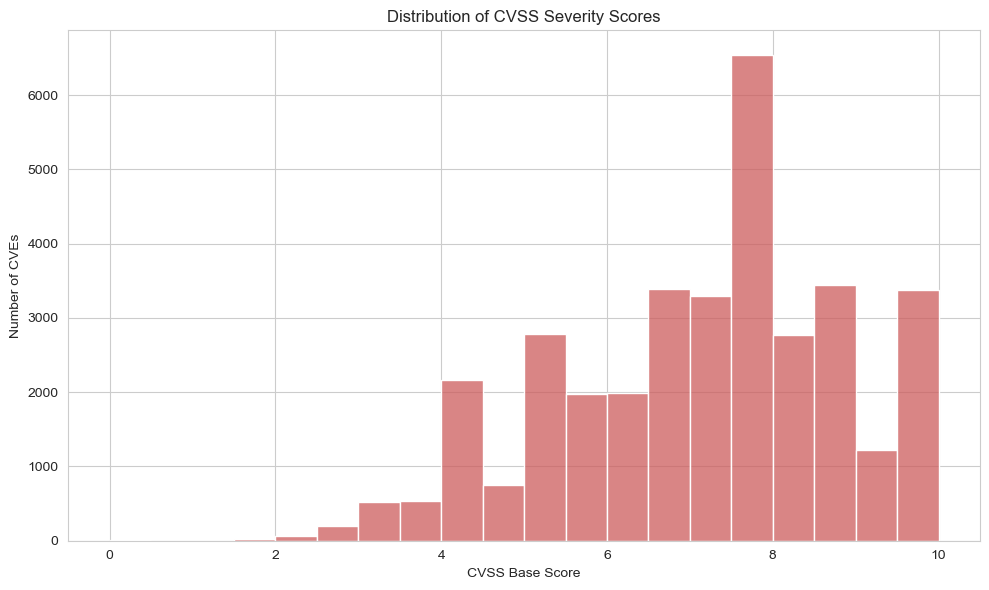

In [10]:
plt.figure(figsize=(10, 6))
sns.histplot(cve['cvss_score'].dropna(), bins=20, color='indianred')
plt.xlabel('CVSS Base Score')
plt.ylabel('Number of CVEs')
plt.title('Distribution of CVSS Severity Scores')
plt.tight_layout()
plt.savefig('figures/07_cvss_score_distribution.png', dpi=150)
plt.show()

## Chart 8 - CVE count per severity category

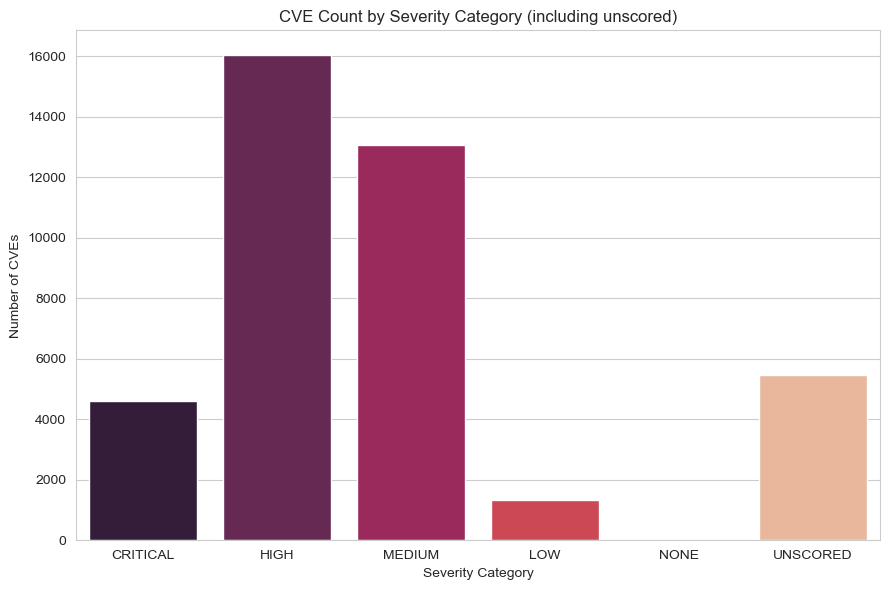

In [11]:
sev_counts = cve['cvss_severity'].fillna('UNSCORED').value_counts()
order = ['CRITICAL', 'HIGH', 'MEDIUM', 'LOW', 'NONE', 'UNSCORED']
sev_counts = sev_counts.reindex([o for o in order if o in sev_counts.index])

plt.figure(figsize=(9, 6))
sns.barplot(x=sev_counts.index, y=sev_counts.values, hue=sev_counts.index, palette="rocket", legend=False)
plt.xlabel('Severity Category')
plt.ylabel('Number of CVEs')
plt.title('CVE Count by Severity Category (including unscored)')
plt.tight_layout()
plt.savefig('figures/08_severity_counts.png', dpi=150)
plt.show()

## Chart 9 - CVEs published over time

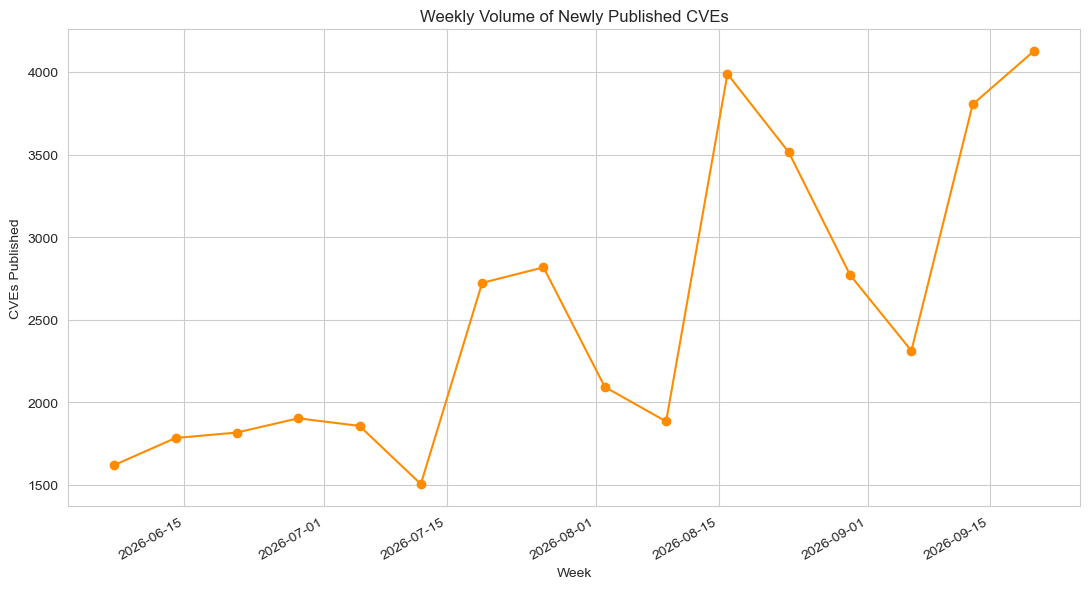

In [12]:
cve['published_date'] = pd.to_datetime(cve['published'])
weekly = cve.set_index('published_date').resample('W').size()

plt.figure(figsize=(11, 6))
plt.plot(weekly.index, weekly.values, marker='o', color='darkorange', linewidth=1.5)
plt.xlabel('Week')
plt.ylabel('CVEs Published')
plt.title('Weekly Volume of Newly Published CVEs')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('figures/09_cves_over_time.png', dpi=150)
plt.show()

## Chart 10 - Top 10 CWE (weakness) categories

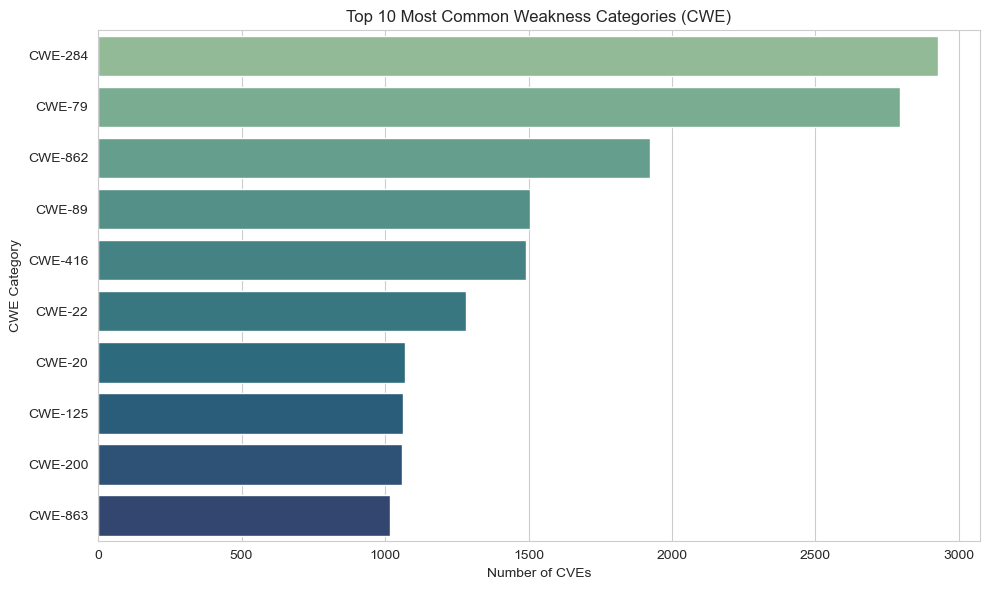

In [13]:
# Some CVEs list multiple CWEs separated by semicolons - split those out before counting
cwe_split = cve['cwe'].dropna().str.split(';').explode().str.strip()
cwe_split = cwe_split[cwe_split != '']
top_cwe = cwe_split.value_counts().head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_cwe.values, y=top_cwe.index, hue=top_cwe.index, palette="crest", legend=False)
plt.xlabel('Number of CVEs')
plt.ylabel('CWE Category')
plt.title('Top 10 Most Common Weakness Categories (CWE)')
plt.tight_layout()
plt.savefig('figures/10_top_cwe_categories.png', dpi=150)
plt.show()

## Chart 11 - Vulnerability description length

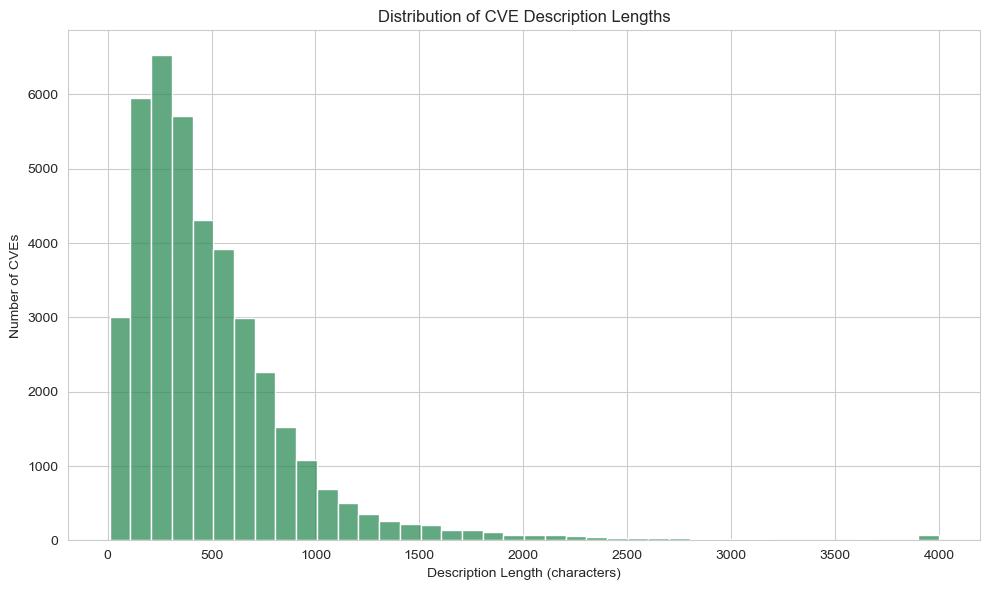

In [14]:
desc_len = cve['description'].dropna().str.len()

plt.figure(figsize=(10, 6))
sns.histplot(desc_len, bins=40, color='seagreen')
plt.xlabel('Description Length (characters)')
plt.ylabel('Number of CVEs')
plt.title('Distribution of CVE Description Lengths')
plt.tight_layout()
plt.savefig('figures/11_description_length.png', dpi=150)
plt.show()